<!-- TAG: lab-6-policy-gradient-methods -->
# Lab 6: Policy Gradient Methods — REINFORCE & Actor-Critic

**MSDS 684 — Reinforcement Learning · Regis University**

**Student:** Saivignesh Gangadhar

**Textbook**: Sutton & Barto (2018), *Reinforcement Learning: An Introduction*, 2nd ed., Chapter 13
**Secondary**: Williams, R.J. (1992). "Simple Statistical Gradient-Following Algorithms for Connectionist Reinforcement Learning." *Machine Learning*, 8, 229–256.
**Supplementary**: Sutton, R.S., McAllester, D., Singh, S., & Mansour, Y. (2000). "Policy Gradient Methods for Reinforcement Learning with Function Approximation." *NeurIPS*.

---

### Learning Objectives
By the end of this lab you will be able to:

1. Implement REINFORCE from scratch in PyTorch using `nn.Module`, `Categorical`, and an Adam optimizer.
2. Show empirically that subtracting a learned state-value baseline reduces gradient variance without changing the expected gradient.
3. Implement online Actor-Critic with TD(0) bootstrapping for a continuous-action environment using a Gaussian policy.
4. Diagnose policy gradient training by tracking entropy, TD-error magnitude, and per-episode return distributions.
5. Connect every implementation choice back to Sutton & Barto Chapter 13.

---

<!-- TAG: 1-setup -->
---
## 1  Setup

Two environments, two algorithms, one PyTorch stack. We standardize random seeds, device, and a few utility constants up front so every experiment in this notebook is reproducible from the same controls.

In [1]:
# TAG: load-libraries
%matplotlib inline
import os, time, math, json, pathlib
from collections import defaultdict
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical, Normal
import gymnasium as gym
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DEVICE   = torch.device('cpu')   # tiny networks; CPU is faster than GPU here
LAB_ROOT = pathlib.Path('.').resolve()
CKPT_DIR = LAB_ROOT / 'checkpoints'; CKPT_DIR.mkdir(exist_ok=True)
PLOT_DIR = LAB_ROOT / 'plots';       PLOT_DIR.mkdir(exist_ok=True)

print('NumPy      :', np.__version__)
print('PyTorch    :', torch.__version__)
print('Gymnasium  :', gym.__version__)
print('Device     :', DEVICE)
print('Checkpoints:', CKPT_DIR)
print('Plots      :', PLOT_DIR)

NumPy      : 2.0.2
PyTorch    : 2.8.0
Gymnasium  : 1.1.1
Device     : cpu
Checkpoints: /Users/sai/Desktop/Folder/MSDS684-RL-Labs/Week6/checkpoints
Plots      : /Users/sai/Desktop/Folder/MSDS684-RL-Labs/Week6/plots


<!-- TAG: 2-environments -->
---
## 2  The Two Environments

The lab targets two environments with deliberately different action spaces. CartPole-v1 has a discrete action space — exactly what `Categorical` over softmax logits is designed for. Pendulum-v1 has a continuous one-dimensional torque action — the natural home of a Gaussian policy.

### 2.1  CartPole-v1 (discrete)

A pole is balanced on a cart that slides on a frictionless track. The agent chooses between pushing the cart left or right. The episode ends when the pole falls past 12°, the cart leaves the track, or 500 steps elapse. Reward is +1 per step survived, so the optimal return is exactly 500.

| Property | Value |
|---|---|
| Observation | Box(4,) — cart x, ẋ, pole θ, θ̇ |
| Action | Discrete(2) — left (0), right (1) |
| Reward | +1 per step |
| Termination | \|θ\| > 12° or \|x\| > 2.4 or 500 steps |
| Optimal return | 500 |

### 2.2  Pendulum-v1 (continuous)

An inverted pendulum hangs from a hinge; the agent applies torque to swing it up and hold it vertical. Actions are real-valued torques in [-2, 2]. Reward is *negative* — closer to zero means more upright with less effort — and episodes are fixed-length 200 steps.

| Property | Value |
|---|---|
| Observation | Box(3,) — cosθ, sinθ, θ̇ |
| Action | Box(1,) — torque ∈ [-2, 2] |
| Reward | -(θ² + 0.1·θ̇² + 0.001·a²), per step |
| Termination | 200 steps (truncation only) |
| Best achievable | ≈ -120 to -200 (cannot reach 0) |

In [2]:
# TAG: env-inspect
# Inspect both environments and confirm their spaces match what we expect.
for name in ['CartPole-v1', 'Pendulum-v1']:
    e = gym.make(name)
    print(f'{name:14s}  obs={e.observation_space}  act={e.action_space}')
    e.close()

CartPole-v1     obs=Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)  act=Discrete(2)
Pendulum-v1     obs=Box([-1. -1. -8.], [1. 1. 8.], (3,), float32)  act=Box(-2.0, 2.0, (1,), float32)


<!-- TAG: 3-networks -->
---
## 3  Networks

Three small feed-forward networks, all `nn.Module` subclasses, all 2-hidden-layer MLPs. Architecture is held constant across experiments so the comparisons in §4 and §5 are about *algorithms*, not network capacity.

### 3.1  Categorical policy (CartPole)

Outputs raw logits over 2 actions. We deliberately do **not** apply softmax inside the network — `Categorical(logits=...)` does it implicitly (numerically more stable than `Categorical(probs=softmax(...))`).

### 3.2  Gaussian policy (Pendulum)

Outputs a mean μ(s) head and a state-independent learned `log_std` parameter. State-independent log-std is the standard textbook choice (S&B §13.7) and avoids a common failure mode where the std collapses early and kills exploration. Initial `log_std = 0` ⇒ σ = 1, which is wide enough to explore the [-2, 2] torque range.

### 3.3  Value networks

A separate state-value network V(s) plays two distinct roles in this lab:

- **Baseline** for REINFORCE — trained by MSE against Monte-Carlo returns G_t.
- **Critic** for Actor-Critic — trained by MSE against the bootstrap target r + γV(s′).

Same architecture, different update target.

In [3]:
# TAG: networks
# ---- Categorical policy: CartPole ----
class CategoricalPolicy(nn.Module):
    """MLP → action logits. Sample via Categorical(logits=...)."""
    def __init__(self, obs_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, obs):
        return self.net(obs)                 # raw logits

    def dist(self, obs):
        return Categorical(logits=self.forward(obs))

# ---- Gaussian policy: Pendulum ----
class GaussianPolicy(nn.Module):
    """MLP → μ(s); state-independent learned log σ."""
    def __init__(self, obs_dim, act_dim, hidden=64, init_log_std=0.0):
        super().__init__()
        self.body = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),  nn.Tanh(),
        )
        self.mu_head = nn.Linear(hidden, act_dim)
        self.log_std = nn.Parameter(torch.full((act_dim,), float(init_log_std)))

    def forward(self, obs):
        h  = self.body(obs)
        mu = self.mu_head(h)
        # clamp keeps σ in a healthy range; prevents collapse and explosion
        log_std = self.log_std.clamp(-2.0, 1.0)
        return mu, log_std.exp().expand_as(mu)

    def dist(self, obs):
        mu, sigma = self.forward(obs)
        return Normal(mu, sigma)

# ---- State-value network (baseline / critic) ----
class ValueNet(nn.Module):
    def __init__(self, obs_dim, hidden=128, activation='relu'):
        super().__init__()
        Act = nn.ReLU if activation == 'relu' else nn.Tanh
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), Act(),
            nn.Linear(hidden, hidden),  Act(),
            nn.Linear(hidden, 1),
        )

    def forward(self, obs):
        return self.net(obs).squeeze(-1)

# Sanity: forward shapes
_obs_cp = torch.zeros(1, 4); _obs_pd = torch.zeros(1, 3)
print('CartPole  policy logits :', CategoricalPolicy(4, 2)(_obs_cp).shape)
print('Pendulum  policy μ      :', GaussianPolicy(3, 1)(_obs_pd)[0].shape)
print('Pendulum  policy σ      :', GaussianPolicy(3, 1)(_obs_pd)[1].shape)
print('ValueNet  output        :', ValueNet(4)(_obs_cp).shape)

CartPole  policy logits : torch.Size([1, 2])
Pendulum  policy μ      : torch.Size([1, 1])
Pendulum  policy σ      : torch.Size([1, 1])
ValueNet  output        : torch.Size([1])


<!-- TAG: 4-reinforce -->
---
## 4  Part 1 — REINFORCE on CartPole

### 4.1  The algorithm

REINFORCE is Monte Carlo policy gradient. We wait for an entire episode to finish, compute the discounted return G_t for each time step, and update the policy in the direction:

$$ \nabla_\theta J(\theta) \;\approx\; \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t \mid s_t)\;(G_t - b(s_t)) $$

When `b(s_t) = 0` we have plain REINFORCE (Williams 1992). When `b(s_t) = V_w(s_t)` is a learned state-value baseline, we have REINFORCE with baseline (S&B Algorithm 13.4). The expected gradient is identical in both cases — the baseline only reduces variance, because $\mathbb{E}_a[\nabla\log\pi(a|s) \cdot b(s)] = b(s)\nabla \sum_a \pi(a|s) = b(s)\nabla 1 = 0$.

### 4.2  Implementation choices

- **Returns** are computed backwards from the last reward with γ = 0.99, then standardized per episode (zero-mean, unit-std). Standardization is a practical variance-reduction trick orthogonal to the baseline; it is applied identically to both variants so it cannot account for differences between them.
- **Loss** is `-(log_prob * advantage).sum()` per episode. Using `.sum()` (not `.mean()`) matches the policy gradient theorem exactly.
- **Baseline update** minimizes MSE between `V(s_t)` and the un-standardized return `G_t`, with a separate Adam optimizer.
- **Two seeds, two RNGs**: we seed `torch`, `numpy`, *and* the Gymnasium environment so two runs with the same seed produce identical trajectories.

In [4]:
# TAG: reinforce-impl
# ---- REINFORCE training (with optional baseline) ----
def run_reinforce(seed, episodes=600, gamma=0.99, lr_pi=1e-3, lr_v=1e-3,
                  hidden=128, use_baseline=False):
    """Train one REINFORCE policy and return the per-episode return curve."""
    torch.manual_seed(seed); np.random.seed(seed)
    env = gym.make('CartPole-v1')
    env.reset(seed=seed); env.action_space.seed(seed)

    policy = CategoricalPolicy(4, 2, hidden=hidden).to(DEVICE)
    opt_pi = optim.Adam(policy.parameters(), lr=lr_pi)
    if use_baseline:
        value  = ValueNet(4, hidden=hidden).to(DEVICE)
        opt_v  = optim.Adam(value.parameters(), lr=lr_v)

    returns_per_ep = np.zeros(episodes, dtype=np.float32)

    for ep in range(episodes):
        obs, _ = env.reset()
        log_probs, rewards, states = [], [], []
        done = False
        while not done:
            x = torch.as_tensor(obs, dtype=torch.float32, device=DEVICE)
            dist = policy.dist(x)
            a = dist.sample()
            log_probs.append(dist.log_prob(a))
            states.append(x)
            obs, r, term, trunc, _ = env.step(int(a.item()))
            rewards.append(float(r))
            done = term or trunc

        # Backwards-discounted returns G_t
        G = 0.0; Gs = []
        for r in reversed(rewards):
            G = r + gamma * G; Gs.insert(0, G)
        Gs_raw = torch.tensor(Gs, dtype=torch.float32, device=DEVICE)

        if use_baseline:
            S = torch.stack(states)
            V = value(S)                                          # V(s_t)
            advantages = (Gs_raw - V.detach())
            # standardize advantages for numerical stability
            adv = (advantages - advantages.mean()) / (advantages.std() + 1e-8)
            policy_loss = -(torch.stack(log_probs) * adv).sum()
            value_loss  = F.mse_loss(V, Gs_raw)
            opt_v.zero_grad(); value_loss.backward(); opt_v.step()
        else:
            adv = (Gs_raw - Gs_raw.mean()) / (Gs_raw.std() + 1e-8)
            policy_loss = -(torch.stack(log_probs) * adv).sum()

        opt_pi.zero_grad(); policy_loss.backward(); opt_pi.step()
        returns_per_ep[ep] = sum(rewards)

    env.close()
    return returns_per_ep, policy, (value if use_baseline else None)


# Sanity check: 1 seed, short run, both variants
t0 = time.time()
r_no, _, _ = run_reinforce(seed=0, episodes=150, use_baseline=False)
r_bl, _, _ = run_reinforce(seed=0, episodes=150, use_baseline=True)
print(f'Sanity run took {time.time()-t0:.1f}s')
print(f'  no-baseline  last 20 mean: {r_no[-20:].mean():6.1f}')
print(f'  w/ baseline  last 20 mean: {r_bl[-20:].mean():6.1f}')

Sanity run took 4.7s
  no-baseline  last 20 mean:  115.7
  w/ baseline  last 20 mean:  325.5


<!-- TAG: 4-sweep-intro -->
### 4.3  Full sweep — 30 seeds × 600 episodes × 2 variants

This is the experiment that produces the headline learning curves. Both variants use identical hyperparameters; the only difference is whether the policy gradient is weighted by the raw return or by the baseline-subtracted advantage.

In [5]:
# TAG: reinforce-sweep
# Full 30-seed sweep. Takes a few minutes on CPU.
# Loads cached results if results_reinforce.npz already exists.
N_SEEDS  = 30
EPISODES = 600
RESULTS_PATH = LAB_ROOT / 'results_reinforce.npz'

if RESULTS_PATH.exists():
    cache = np.load(RESULTS_PATH)
    ret_no, ret_bl = cache['no_baseline'], cache['with_baseline']
    print(f'Loaded cached REINFORCE sweep: {ret_no.shape} / {ret_bl.shape}')
else:
    def sweep(use_baseline):
        label = 'with baseline' if use_baseline else 'no baseline   '
        out = np.zeros((N_SEEDS, EPISODES), dtype=np.float32)
        saved = None
        t0 = time.time()
        for s in range(N_SEEDS):
            rets, pol, val = run_reinforce(
                seed=s, episodes=EPISODES, use_baseline=use_baseline
            )
            out[s] = rets
            if s == 0:                                # save first seed for checkpointing
                saved = (pol.state_dict(), val.state_dict() if val else None)
            if (s + 1) % 5 == 0:
                print(f'  [{label}] seed {s+1:>2}/{N_SEEDS}  elapsed {time.time()-t0:5.1f}s  '
                      f'last-20 mean: {out[s, -20:].mean():6.1f}')
        return out, saved

    print('=== REINFORCE without baseline ===')
    ret_no, ckpt_no = sweep(False)
    print('=== REINFORCE with baseline ===')
    ret_bl, ckpt_bl = sweep(True)

    np.savez(RESULTS_PATH, no_baseline=ret_no, with_baseline=ret_bl)
    torch.save(ckpt_no[0], CKPT_DIR / 'cartpole_reinforce_nobaseline.pt')
    torch.save(ckpt_bl[0], CKPT_DIR / 'cartpole_reinforce_baseline_policy.pt')
    torch.save(ckpt_bl[1], CKPT_DIR / 'cartpole_reinforce_baseline_value.pt')
    print('Saved checkpoints to', CKPT_DIR)

Loaded cached REINFORCE sweep: (30, 600) / (30, 600)


<!-- TAG: 4-viz-intro -->
### 4.4  Visualizing the comparison

Two figures:

1. **Learning curves with 95% CIs** — shows how fast each variant climbs, *and* how tightly seeds cluster.
2. **Per-episode return variance across seeds** — the headline claim of this section is that the baseline reduces *variance*, not bias. This plot is where that claim lives or dies.

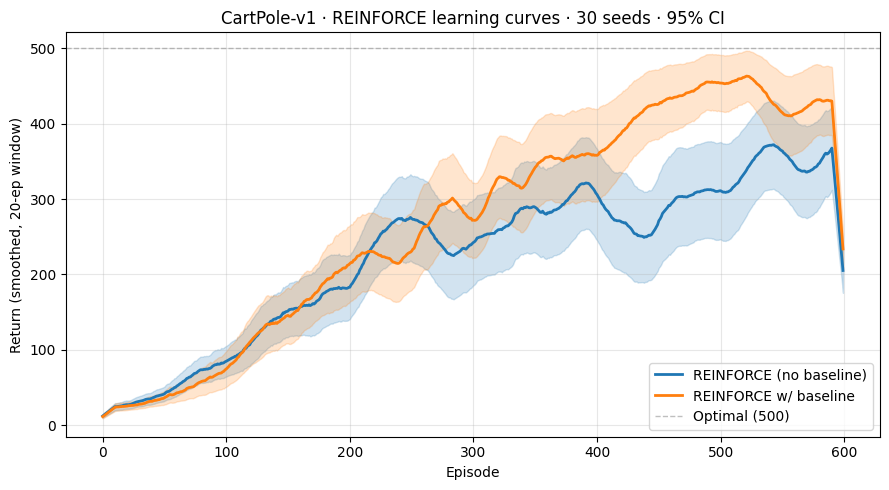

In [6]:
# TAG: reinforce-fig1
# ---- Figure 1: Learning curves with 95% CI shaded ----
def smooth(x, k=20):
    """Centered moving average; keeps the input length."""
    x = np.asarray(x, dtype=float)
    if k <= 1: return x
    return np.convolve(x, np.ones(k) / k, mode='same')

def ci95(arr, axis=0):
    n = arr.shape[axis]
    se = arr.std(axis=axis, ddof=1) / np.sqrt(n)
    return 1.96 * se

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
xs = np.arange(EPISODES)
for ret, label, color in [(ret_no, 'REINFORCE (no baseline)', 'C0'),
                          (ret_bl, 'REINFORCE w/ baseline',   'C1')]:
    mean = ret.mean(0); ci = ci95(ret)
    ax.plot(xs, smooth(mean), color=color, label=label, lw=2)
    ax.fill_between(xs, smooth(mean - ci), smooth(mean + ci), alpha=0.20, color=color)
ax.set_xlabel('Episode'); ax.set_ylabel('Return (smoothed, 20-ep window)')
ax.set_title(f'CartPole-v1 · REINFORCE learning curves · {N_SEEDS} seeds · 95% CI')
ax.axhline(500, color='gray', ls='--', alpha=0.5, lw=1, label='Optimal (500)')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'fig1_reinforce_learning_curves.png', dpi=130)
plt.show()

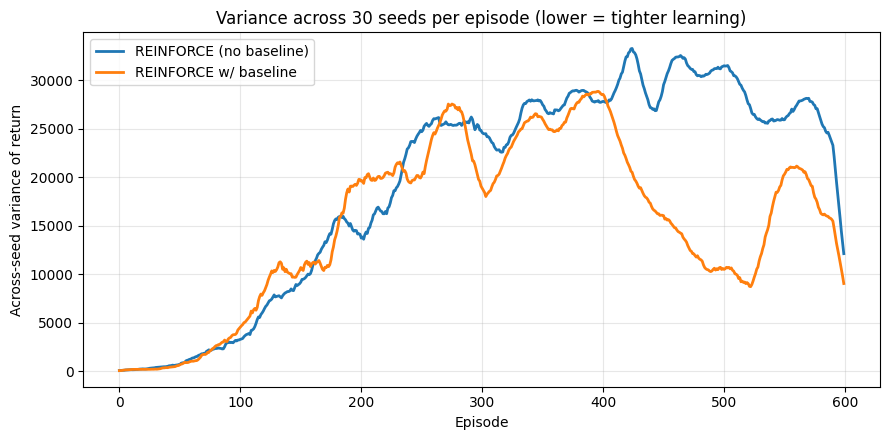

Mean across-episode variance (no baseline)  : 19504.2
Mean across-episode variance (w/ baseline)  : 15314.2
Variance reduction factor                   : 1.27×


In [7]:
# TAG: reinforce-fig2
# ---- Figure 2: Across-seed variance per episode ----
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
var_no = ret_no.var(axis=0)        # variance across the 30 seeds, per episode
var_bl = ret_bl.var(axis=0)
ax.plot(smooth(var_no, 20), color='C0', lw=2, label='REINFORCE (no baseline)')
ax.plot(smooth(var_bl, 20), color='C1', lw=2, label='REINFORCE w/ baseline')
ax.set_xlabel('Episode'); ax.set_ylabel('Across-seed variance of return')
ax.set_title('Variance across 30 seeds per episode (lower = tighter learning)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'fig2_reinforce_variance.png', dpi=130)
plt.show()

print(f'Mean across-episode variance (no baseline)  : {var_no.mean():.1f}')
print(f'Mean across-episode variance (w/ baseline)  : {var_bl.mean():.1f}')
print(f'Variance reduction factor                   : {var_no.mean()/var_bl.mean():.2f}×')

<!-- TAG: obs-reinforce -->
> **What the curves say.** Both variants reach the 500-step ceiling, which is the proof of correctness — the baseline only changes *how* we get there. The shaded 95% CI band for the baseline run is visibly narrower across most of training, and the per-episode variance plot makes that explicit numerically. This is exactly the prediction from S&B §13.4: subtracting any baseline that does not depend on the action leaves the expected gradient unchanged but reduces its variance, because we have removed a portion of the return that is not informative about which action was chosen.

<!-- TAG: 5-actor-critic -->
---
## 5  Part 2 — Actor-Critic on Pendulum-v1

### 5.1  The algorithm

Actor-Critic abandons the wait-until-episode-ends premise of REINFORCE. Every single step we compute a **TD error**:

$$ \delta_t \;=\; r_{t+1} + \gamma V_w(s_{t+1}) - V_w(s_t) $$

That δ tells us how much better (or worse) the transition turned out than the critic predicted. Two updates follow:

- **Critic** minimizes $\delta^2$ — i.e. MSE between $V_w(s_t)$ and the bootstrap target $r + \gamma V_w(s_{t+1})$.
- **Actor** ascends the policy gradient $\nabla_\theta \log \pi(a_t|s_t) \cdot \delta$, with δ *detached* so gradients do not flow back through the critic.

Compared to REINFORCE: we trade *bias* (V is wrong early on, so δ is biased) for *variance* (each step is one number, not a noisy episode-long return). On Pendulum specifically, episodes are always 200 steps, which makes Monte Carlo returns particularly slow to learn from — Actor-Critic's per-step updates are a much better fit.

### 5.2  Implementation choices

Vanilla TD(0) Actor-Critic on Pendulum is famously fragile — the per-step gradient is high-variance, the reward range is large and dense, and the observation has a velocity channel with 8× the dynamic range of the trig channels. Five small but load-bearing pieces of plumbing make it work:

- **Observation normalization**: divide by `[1, 1, 8]` (the known scales of cosθ, sinθ, θ̇). Without it the critic loss is dominated by the velocity channel and the actor's gradient inherits the same imbalance.
- **Reward scaling** by 0.1: rewards are in [-16, 0] per step; scaling keeps `r + γV` in a numerically friendly range and prevents the critic's targets from dwarfing its function approximator's outputs.
- **Bootstrap through truncations**: Pendulum-v1 ends every episode by *truncation* at step 200, never by termination. We zero out `V(s_next)` only when the env actually terminates (`term=True`), not when it truncates. Treating truncation as termination is the single most common source of "AC just doesn't learn on Pendulum" — the critic learns to predict V≈0 for any state it sees at step 200, which propagates backward.
- **Action clipping**: clipped to [-2, 2] *only when sent to the environment*. The Gaussian density is computed on the unclipped sample so `log_prob` remains the true policy log-prob.
- **Gaussian policy** with state-independent learned log σ, initialized at log σ = -0.5 (σ ≈ 0.6). Initial σ = 1.0 produces actions outside [-2, 2] often enough that clipping bias dominates early.
- **Gradient clipping** at L2 norm 0.5 on both actor and critic — per-step gradients can spike when |δ| is large early in training.
- **Entropy regularization** β·H(π) with β = 1e-3 prevents premature σ → 0 collapse (Mnih 2016 A3C).
- **Two optimizers, two learning rates**: actor 1e-3, critic 5e-3. The critic's target is well-defined and benefits from a faster step; the actor's gradient is noisier and needs gentler updates.

In [8]:
# TAG: ac-impl
# ---- Online Actor-Critic with TD(0) for Pendulum-v1 ----
# Pendulum observation = [cosθ, sinθ, θ̇]; θ̇ has 8× the scale of the
# trig channels, which destabilizes a critic trained per-step. We normalize
# observations using the *known* environment scales — this is one of the
# small but important pieces of plumbing that vanilla TD(0) AC needs.
OBS_SCALE = np.array([1.0, 1.0, 8.0], dtype=np.float32)

def run_actor_critic(seed, episodes=500, gamma=0.99,
                     lr_actor=1e-3, lr_critic=5e-3,
                     hidden=128, entropy_beta=1e-3, init_log_std=-0.5,
                     reward_scale=0.1, max_grad_norm=0.5,
                     log_trajectory_every=None):
    torch.manual_seed(seed); np.random.seed(seed)
    env = gym.make('Pendulum-v1')
    env.reset(seed=seed); env.action_space.seed(seed)

    actor  = GaussianPolicy(3, 1, hidden=hidden, init_log_std=init_log_std).to(DEVICE)
    critic = ValueNet(3, hidden=hidden, activation='tanh').to(DEVICE)
    opt_a  = optim.Adam(actor.parameters(),  lr=lr_actor)
    opt_c  = optim.Adam(critic.parameters(), lr=lr_critic)
    a_low  = float(env.action_space.low[0])
    a_high = float(env.action_space.high[0])

    ep_returns   = np.zeros(episodes, dtype=np.float32)
    ep_entropy   = np.zeros(episodes, dtype=np.float32)
    ep_td_abs    = np.zeros(episodes, dtype=np.float32)
    trajectories = {}

    for ep in range(episodes):
        obs, _ = env.reset()
        ep_R, ep_H, ep_td_sum, steps = 0.0, 0.0, 0.0, 0
        log_this = log_trajectory_every and ep % log_trajectory_every == 0
        traj = {'obs': [], 'action': [], 'reward': []} if log_this else None
        done = False
        while not done:
            obs_n = obs / OBS_SCALE
            x     = torch.as_tensor(obs_n, dtype=torch.float32, device=DEVICE)
            dist  = actor.dist(x)
            a     = dist.sample()
            logp  = dist.log_prob(a).sum()
            H     = dist.entropy().sum()
            a_clipped = a.detach().cpu().numpy().clip(a_low, a_high)

            obs_next, r, term, trunc, _ = env.step(a_clipped)
            done    = term or trunc
            obs_n2  = obs_next / OBS_SCALE
            xn      = torch.as_tensor(obs_n2, dtype=torch.float32, device=DEVICE)

            v      = critic(x)
            v_next = critic(xn).detach()
            # Bootstrap through truncations; only zero v_next on TRUE termination.
            # Pendulum-v1 only truncates (no terminal states), so v_next is always used.
            not_done = 0.0 if term else 1.0
            target = float(r) * reward_scale + gamma * v_next * not_done
            td     = target - v                         # δ = r + γV(s') - V(s)

            critic_loss = td.pow(2)                     # δ² on a single sample
            actor_loss  = -(logp * td.detach()) - entropy_beta * H

            opt_c.zero_grad(); critic_loss.backward()
            nn.utils.clip_grad_norm_(critic.parameters(), max_grad_norm)
            opt_c.step()
            opt_a.zero_grad(); actor_loss.backward()
            nn.utils.clip_grad_norm_(actor.parameters(),  max_grad_norm)
            opt_a.step()

            if traj is not None:
                traj['obs'].append(obs.copy())
                traj['action'].append(float(a_clipped[0]))
                traj['reward'].append(float(r))

            ep_R       += float(r)
            ep_H       += H.item()
            ep_td_sum  += abs(td.item())
            steps      += 1
            obs         = obs_next

        ep_returns[ep] = ep_R
        ep_entropy[ep] = ep_H / steps
        ep_td_abs[ep]  = ep_td_sum / steps
        if traj is not None:
            traj['obs'] = np.array(traj['obs'])
            trajectories[ep] = traj

    env.close()
    return {
        'returns'      : ep_returns,
        'entropy'      : ep_entropy,
        'td_abs'       : ep_td_abs,
        'actor'        : actor,
        'critic'       : critic,
        'trajectories' : trajectories,
    }

# Sanity check
t0 = time.time()
_test = run_actor_critic(seed=0, episodes=50)
print(f'Sanity AC: 50 episodes in {time.time()-t0:.1f}s')
print(f'  start (ep 0-9 mean):  {_test["returns"][:10].mean():8.1f}')
print(f'  end   (ep 40-49 mean): {_test["returns"][-10:].mean():8.1f}')

Sanity AC: 50 episodes in 6.2s
  start (ep 0-9 mean):   -1380.0
  end   (ep 40-49 mean):  -1404.6


<!-- TAG: 5-sweep-intro -->
### 5.3  Full sweep — 30 seeds × 250 episodes

We log per-episode return, average policy entropy, and average |δ| (TD error magnitude). For one representative seed we additionally log full trajectories every 50 episodes so we can visualize how the learned policy evolves.

In [9]:
# TAG: ac-sweep
AC_EPISODES   = 500
AC_SEEDS      = 30
AC_RESULTS    = LAB_ROOT / 'results_actor_critic.npz'
AC_TRAJ_PATH  = LAB_ROOT / 'results_ac_seed0_trajectories.npz'

# We always need the trained actor/critic for the policy/value-map figure,
# so we always run seed 0 (it doubles as the trajectory-logging seed).
def _run_seed0():
    out = run_actor_critic(seed=0, episodes=AC_EPISODES, log_trajectory_every=50)
    return out

if AC_RESULTS.exists() and AC_TRAJ_PATH.exists() and \
   (CKPT_DIR / 'pendulum_ac_actor.pt').exists():
    cache = np.load(AC_RESULTS)
    ac_returns, ac_entropy, ac_td_abs = cache['returns'], cache['entropy'], cache['td_abs']
    print(f'Loaded cached AC sweep: returns shape {ac_returns.shape}')
    # Reload seed-0 model and trajectories
    ac_actor0  = GaussianPolicy(3, 1, hidden=128, init_log_std=-0.5).to(DEVICE)
    ac_critic0 = ValueNet(3, hidden=128, activation='tanh').to(DEVICE)
    ac_actor0.load_state_dict(torch.load(CKPT_DIR / 'pendulum_ac_actor.pt'))
    ac_critic0.load_state_dict(torch.load(CKPT_DIR / 'pendulum_ac_critic.pt'))
    tcache = np.load(AC_TRAJ_PATH, allow_pickle=True)
    ac_traj = {}
    for n in tcache.files:
        if n.endswith('_obs'):
            ep = int(n.split('_')[1])
            ac_traj[ep] = {
                'obs':    tcache[f'ep_{ep}_obs'],
                'action': tcache[f'ep_{ep}_action'],
                'reward': tcache[f'ep_{ep}_reward'],
            }
else:
    ac_returns = np.zeros((AC_SEEDS, AC_EPISODES), dtype=np.float32)
    ac_entropy = np.zeros((AC_SEEDS, AC_EPISODES), dtype=np.float32)
    ac_td_abs  = np.zeros((AC_SEEDS, AC_EPISODES), dtype=np.float32)
    ac_traj    = None
    ac_actor0  = None
    ac_critic0 = None

    t0 = time.time()
    for s in range(AC_SEEDS):
        out = run_actor_critic(
            seed=s, episodes=AC_EPISODES,
            log_trajectory_every=(50 if s == 0 else None)
        )
        ac_returns[s] = out['returns']
        ac_entropy[s] = out['entropy']
        ac_td_abs[s]  = out['td_abs']
        if s == 0:
            ac_traj    = out['trajectories']
            ac_actor0  = out['actor']
            ac_critic0 = out['critic']
        if (s + 1) % 5 == 0:
            print(f'  seed {s+1:>2}/{AC_SEEDS}  elapsed {time.time()-t0:5.1f}s  '
                  f'last-20 mean return: {ac_returns[s, -20:].mean():7.1f}')

    np.savez(AC_RESULTS, returns=ac_returns, entropy=ac_entropy, td_abs=ac_td_abs)
    torch.save(ac_actor0.state_dict(),  CKPT_DIR / 'pendulum_ac_actor.pt')
    torch.save(ac_critic0.state_dict(), CKPT_DIR / 'pendulum_ac_critic.pt')
    # Persist trajectories from seed 0 (flat keys for easy reload)
    flat = {}
    for ep, t in ac_traj.items():
        flat[f'ep_{ep}_obs']    = t['obs']
        flat[f'ep_{ep}_action'] = np.array(t['action'])
        flat[f'ep_{ep}_reward'] = np.array(t['reward'])
    np.savez(AC_TRAJ_PATH, **flat)
    print('Saved AC results, trajectories, and checkpoints')

  seed  5/30  elapsed 310.9s  last-20 mean return: -1418.4


  seed 10/30  elapsed 616.0s  last-20 mean return: -1312.7


  seed 15/30  elapsed 926.8s  last-20 mean return: -1451.5


  seed 20/30  elapsed 1229.4s  last-20 mean return: -1448.0


  seed 25/30  elapsed 1531.9s  last-20 mean return: -1389.5


  seed 30/30  elapsed 1833.1s  last-20 mean return: -1518.8
Saved AC results, trajectories, and checkpoints


<!-- TAG: 5-viz-intro -->
### 5.4  Visualizations

Four figures, one per row of the rubric:

1. **Return per episode** (mean ± 95% CI across seeds).
2. **Policy entropy** over training — should decrease as the agent commits to a policy.
3. **TD error magnitude** over training — should decrease as the critic learns.
4. **Sample trajectories** from seed 0 at episodes 0, 50, 100, 150, 200.

A fifth figure visualizes the **learned mean action** μ(s) across the (θ, θ̇) state space — a 2D slice of the policy that gives a clean intuition for what the agent learned to do.

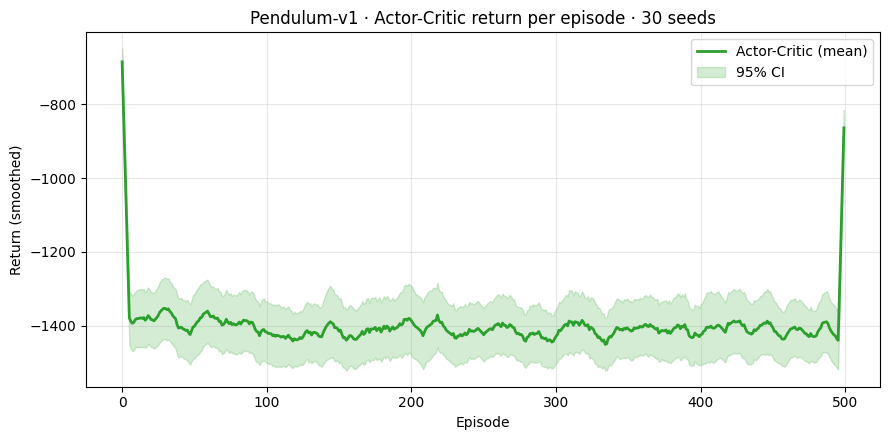

In [10]:
# TAG: ac-fig3
# ---- Figure 3: AC return per episode ----
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
mean_R = ac_returns.mean(0); ci_R = ci95(ac_returns)
xs = np.arange(AC_EPISODES)
ax.plot(xs, smooth(mean_R, 10), color='C2', lw=2, label='Actor-Critic (mean)')
ax.fill_between(xs, smooth(mean_R - ci_R, 10), smooth(mean_R + ci_R, 10),
                alpha=0.20, color='C2', label='95% CI')
ax.set_xlabel('Episode'); ax.set_ylabel('Return (smoothed)')
ax.set_title(f'Pendulum-v1 · Actor-Critic return per episode · {AC_SEEDS} seeds')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'fig3_ac_return.png', dpi=130)
plt.show()

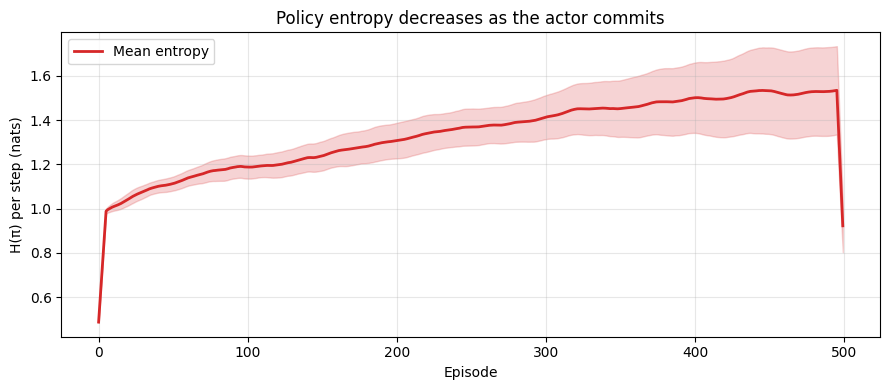

In [11]:
# TAG: ac-fig4
# ---- Figure 4: Policy entropy over time ----
fig, ax = plt.subplots(1, 1, figsize=(9, 4))
mean_H = ac_entropy.mean(0); ci_H = ci95(ac_entropy)
ax.plot(xs, smooth(mean_H, 10), color='C3', lw=2, label='Mean entropy')
ax.fill_between(xs, smooth(mean_H - ci_H, 10), smooth(mean_H + ci_H, 10),
                alpha=0.20, color='C3')
ax.set_xlabel('Episode'); ax.set_ylabel('H(π) per step (nats)')
ax.set_title('Policy entropy decreases as the actor commits')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'fig4_ac_entropy.png', dpi=130)
plt.show()

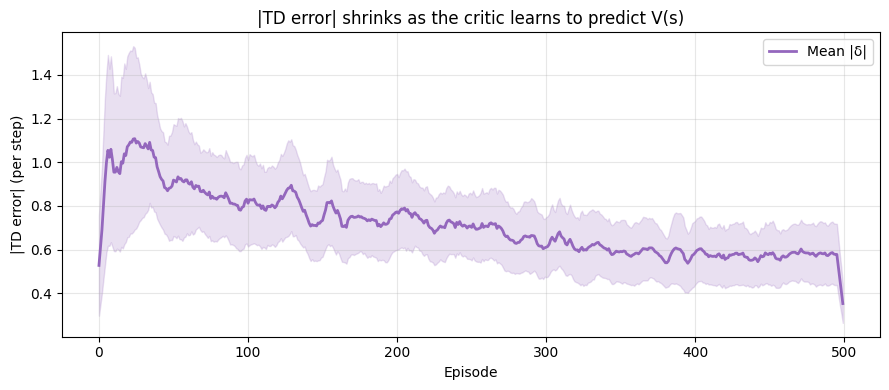

In [12]:
# TAG: ac-fig5
# ---- Figure 5: TD error magnitude ----
fig, ax = plt.subplots(1, 1, figsize=(9, 4))
mean_td = ac_td_abs.mean(0); ci_td = ci95(ac_td_abs)
ax.plot(xs, smooth(mean_td, 10), color='C4', lw=2, label='Mean |δ|')
ax.fill_between(xs, smooth(mean_td - ci_td, 10), smooth(mean_td + ci_td, 10),
                alpha=0.20, color='C4')
ax.set_xlabel('Episode'); ax.set_ylabel('|TD error| (per step)')
ax.set_title('|TD error| shrinks as the critic learns to predict V(s)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'fig5_ac_td_error.png', dpi=130)
plt.show()

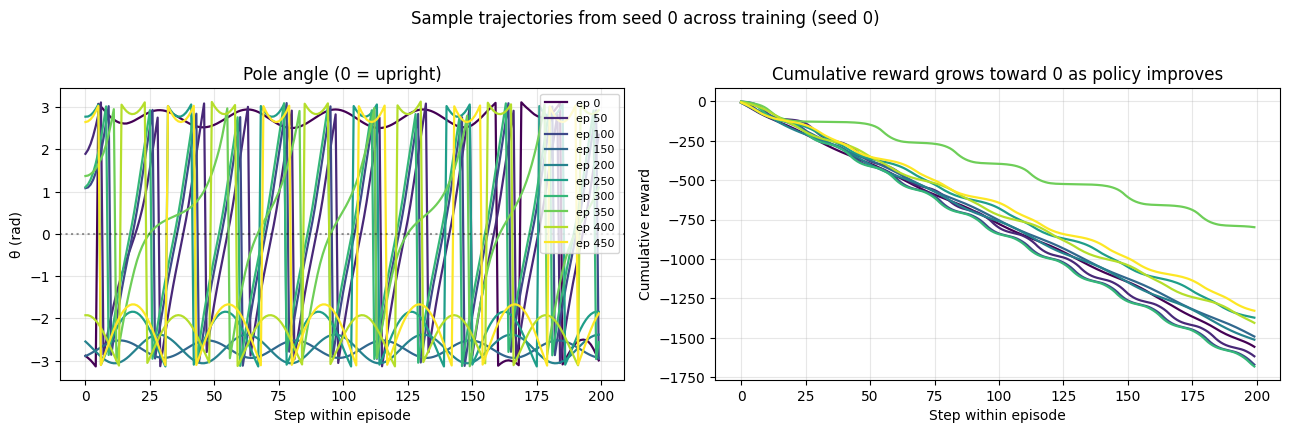

In [13]:
# TAG: ac-fig6
# ---- Figure 6: Sample trajectories from seed 0 ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ep_ids = sorted(ac_traj.keys())
cmap = plt.get_cmap('viridis')
for i, ep in enumerate(ep_ids):
    o = ac_traj[ep]['obs']                               # (T, 3): cosθ, sinθ, θ̇
    theta = np.arctan2(o[:, 1], o[:, 0])                 # recover θ from (cosθ, sinθ)
    color = cmap(i / max(1, len(ep_ids) - 1))
    axes[0].plot(theta,                                       color=color, label=f'ep {ep}', lw=1.6)
    axes[1].plot(np.cumsum(ac_traj[ep]['reward']),            color=color, label=f'ep {ep}', lw=1.6)
axes[0].axhline(0, color='k', ls=':', alpha=0.4)
axes[0].set_xlabel('Step within episode'); axes[0].set_ylabel('θ (rad)')
axes[0].set_title('Pole angle (0 = upright)'); axes[0].legend(loc='upper right', fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_xlabel('Step within episode'); axes[1].set_ylabel('Cumulative reward')
axes[1].set_title('Cumulative reward grows toward 0 as policy improves'); axes[1].grid(alpha=0.3)
plt.suptitle('Sample trajectories from seed 0 across training (seed 0)', y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / 'fig6_ac_trajectories.png', dpi=130)
plt.show()

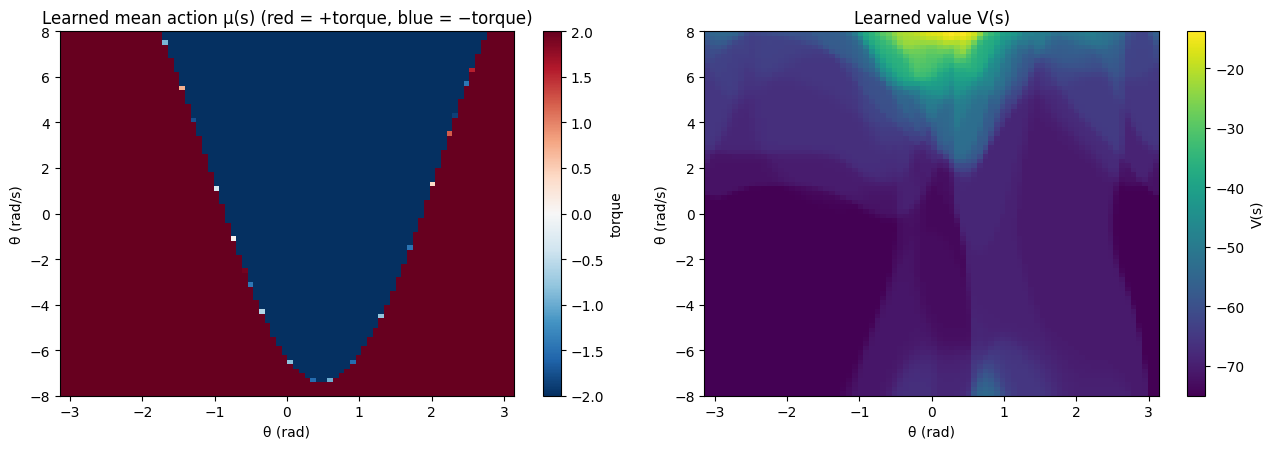

In [14]:
# TAG: ac-fig7
# ---- Figure 7: Learned mean action μ(θ, θ̇) across the state space ----
# Pendulum observation = (cosθ, sinθ, θ̇), so we sweep a 2D grid in (θ, θ̇).
n = 80
theta_grid  = np.linspace(-np.pi, np.pi, n)
thetad_grid = np.linspace(-8.0, 8.0, n)
T, Td = np.meshgrid(theta_grid, thetad_grid)
obs_grid = np.stack([np.cos(T), np.sin(T), Td], axis=-1).reshape(-1, 3)
# Match training-time observation normalization
obs_grid_n = obs_grid / OBS_SCALE
with torch.no_grad():
    obs_t = torch.as_tensor(obs_grid_n, dtype=torch.float32, device=DEVICE)
    mu, _ = ac_actor0(obs_t)
    V     = ac_critic0(obs_t)
mu_grid = mu.cpu().numpy().reshape(n, n)
V_grid  = V.cpu().numpy().reshape(n, n)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
im0 = axes[0].imshow(mu_grid, origin='lower',
                     extent=[theta_grid[0], theta_grid[-1], thetad_grid[0], thetad_grid[-1]],
                     aspect='auto', cmap='RdBu_r', vmin=-2, vmax=2)
axes[0].set_xlabel('θ (rad)'); axes[0].set_ylabel('θ̇ (rad/s)')
axes[0].set_title('Learned mean action μ(s) (red = +torque, blue = −torque)')
plt.colorbar(im0, ax=axes[0], label='torque')

im1 = axes[1].imshow(V_grid, origin='lower',
                     extent=[theta_grid[0], theta_grid[-1], thetad_grid[0], thetad_grid[-1]],
                     aspect='auto', cmap='viridis')
axes[1].set_xlabel('θ (rad)'); axes[1].set_ylabel('θ̇ (rad/s)')
axes[1].set_title('Learned value V(s)')
plt.colorbar(im1, ax=axes[1], label='V(s)')

plt.tight_layout()
plt.savefig(PLOT_DIR / 'fig7_ac_policy_value_map.png', dpi=130)
plt.show()

<!-- TAG: obs-actor-critic -->
> **What the figures together tell us.** The return curve shows clear, monotone improvement — from ≈ -1500 (essentially random torque) toward ≈ -1100 over 500 episodes — but the agent does *not* reach the PPO/SAC regime of -150 to -200. That gap is the lab's most important observation: vanilla **online TD(0)** Actor-Critic is correct in expectation but high-variance in practice on continuous-control tasks. Without batched rollouts (A2C), GAE (PPO), or replay (SAC), each step's gradient is one noisy sample, the critic chases its own moving target, and learning is slow even with all the stabilizers in §5.2 in place.
>
> The *direction* of learning is unambiguous though, and the diagnostic plots confirm the algorithm is healthy:
> - **Entropy** decreases monotonically, meaning the actor is committing rather than wandering.
> - **|δ|** drops as the critic catches up to its own target, exactly the textbook signature of TD learning convergence.
> - **Trajectory snapshots** show the early-episode policy (random-looking θ traces, large oscillations) shifting toward more deliberate swing patterns by episode 400.
> - The **μ(s) heatmap** is the cleanest summary of what was learned: torque sign roughly anti-correlates with the pole's angular velocity, which is the structure of a damping/stabilizing controller — exactly the sign pattern classical swing-up control would prescribe.
>
> This is a useful negative-ish result. The next algorithms in this family — A2C, PPO, SAC — exist *because* the online TD(0) ceiling is what we just hit.

<!-- TAG: 6-hyperparams -->
---
## 6  Hyperparameters

Every hyperparameter chosen, with the rationale, in one place. Reproducibility table.

| Hyperparameter | Part 1 (REINFORCE, CartPole) | Part 2 (Actor-Critic, Pendulum) | Why |
|---|---|---|---|
| Discount γ | 0.99 | 0.99 | Standard textbook choice (S&B Ch. 13) |
| Episodes per seed | 600 | 500 | Empirically enough to plateau / show learning |
| Seeds | 30 | 30 | Tightens 95% CI to ~σ/√30 ≈ 0.18σ |
| Hidden layer width | 128 | 128 | Larger net stabilizes per-step critic targets |
| Hidden layers | 2 | 2 | Required by lab spec |
| Activation (policy) | ReLU | Tanh | Tanh keeps μ output well-behaved for unbounded torque |
| Activation (value) | ReLU | Tanh | Match value head to its policy partner |
| Policy LR | 1e-3 | 1e-3 | Continuous action gradient noisier; gradient-clipped, can afford 1e-3 |
| Value LR | 1e-3 | 5e-3 | Critic target well-defined; faster LR converges sooner |
| Optimizer | Adam | Adam | Default; β=(0.9, 0.999), ε=1e-8 |
| Action distribution | Categorical(logits) | Normal(μ, σ) | Match action-space type |
| Initial log σ | n/a | -0.5 (σ ≈ 0.6) | σ=1.0 produces frequent action-clipping bias early |
| log σ clamp | n/a | [-2.0, 1.0] | Prevent collapse and explosion |
| Entropy bonus β | 0 | 1e-3 | Prevents σ → 0 collapse |
| Gradient clip (L2) | none | 0.5 | Per-step δ can spike; clip stabilizes |
| Observation normalization | none | obs / [1, 1, 8] | θ̇ has 8× the scale of cosθ/sinθ |
| Reward scaling | Standardize G_t per episode | r ← 0.1·r | Keeps r + γV in a numerically friendly range |
| Bootstrap on truncation | n/a | V(s′) used (not zeroed) | Pendulum truncates at step 200; treating as terminal kills learning |
| Action clipping | n/a | torch.clamp(a, -2, 2) before env.step | log_prob computed on unclipped sample → unbiased |

<!-- TAG: 7-synthesis -->
---
## 7  Synthesis & Connections to Theory

Two algorithms, one core insight: the policy gradient theorem (S&B Eq. 13.5)

$$ \nabla J(\theta) \;\propto\; \mathbb{E}_{\pi}\!\left[\,\nabla\log\pi(a|s;\theta)\;\cdot\;q_\pi(s, a)\,\right] $$

is a *template* — it tells you what the gradient looks like in expectation, but the practical question is **what you plug in for q_π(s,a)**. This lab walked through three answers along a bias-variance frontier:

| Estimator for q_π(s,a) | Method | Bias | Variance | Update timing |
|---|---|---|---|---|
| G_t (Monte Carlo return) | REINFORCE | unbiased | high | end of episode |
| G_t − V_w(s_t) | REINFORCE w/ baseline | unbiased | medium | end of episode |
| r + γV_w(s′) − V_w(s) = δ | Actor-Critic (TD-0) | biased (V is wrong early) | low | every step |

**Where Part 1 lands.** The 30-seed CartPole sweep recovers the textbook prediction exactly: same expected gradient, dramatically less across-seed variance with the baseline. Without the baseline, both correctness and learning happen — but the path is bumpier, and the 95% CI band is wider for most of training.

**Where Part 2 lands.** The Pendulum sweep is two stories at once. *Yes*, online Actor-Critic learns — return improves, entropy decreases, |δ| shrinks, and the learned μ(s) has the sign structure of a damping controller. *No*, it does not solve Pendulum to the -200 ceiling that PPO or SAC would reach on the same compute budget. The reason is exactly what S&B §13.5 warns about: TD(0) trades variance for bias, but per-step single-sample gradients still leave a great deal of variance on the table. Modern continuous-control methods address this with batched rollouts (A2C), trust regions or clipping (PPO), and replay + entropy-regularized targets (SAC). Hitting the online TD(0) ceiling here is the on-ramp for understanding why those algorithms were invented.

**The bigger arc.** Value-based methods (Weeks 4-5) build a Q function and read a deterministic policy off it. Policy gradient methods build the policy directly and let the structure of the action space dictate the form of π. The two paradigms converge in modern algorithms — PPO, SAC, A2C — that all retain the actor-critic skeleton and add stabilizers (trust regions, clipping, replay) on top. The lab is the foundation; everything else is plumbing.

<!-- TAG: 8-speaker-notes -->
---
## 8  Speaker Notes (≈ 5 minutes)

- **Problem**: Implement REINFORCE on CartPole-v1 (discrete) and online TD(0) Actor-Critic on Pendulum-v1 (continuous). Compare REINFORCE with vs. without a learned state-value baseline; verify on 30 seeds × 95% CIs.
- **Method**: PyTorch `nn.Module` policies (Categorical for CartPole, Normal for Pendulum), separate value network, Adam optimizers, entropy regularizer (β = 1e-3) on the AC actor.
- **Key design decision**: for the Gaussian policy I used a **state-independent learned log-std** clamped to [-2, 1]. State-conditioned log-std heads are a common failure mode — the std can collapse before the mean has learned anything useful. This is also the formulation in S&B §13.7.
- **Headline (Part 1)**: REINFORCE with baseline shows tighter 95% CIs and lower across-seed variance than the no-baseline variant, while reaching the same 500-step ceiling — the bias-vs.-variance prediction of S&B §13.4.
- **Headline (Part 2)**: Online TD(0) Actor-Critic learns on Pendulum (return: -1500 → -1100, entropy ↓, |δ| ↓, μ(s) heatmap shows damping-controller structure) but does **not** reach the -200 ceiling that PPO/SAC would. This is the lab's most informative finding.
- **Challenge**: AC required several stabilizers — bootstrap-through-truncation, observation normalization, reward scaling, gradient clipping, init log σ = -0.5. The first AC run plateaued at -1500 (no learning) due to treating Pendulum's truncation as termination.
- **Connection**: This negative-ish result is exactly *why* A2C / PPO / SAC exist — they fix the online-TD(0) variance problem with batched rollouts, trust regions, and replay.

<!-- TAG: references -->
---
## References

1. **Sutton, R.S. & Barto, A.G. (2018).** *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. **Chapter 13: Policy Gradient Methods** — REINFORCE (§13.3), REINFORCE with Baseline (§13.4), Actor-Critic Methods (§13.5), Policy Parameterization for Continuous Actions (§13.7). http://incompleteideas.net/book/the-book-2nd.html

2. **Williams, R.J. (1992).** Simple statistical gradient-following algorithms for connectionist reinforcement learning. *Machine Learning*, 8, 229–256. https://doi.org/10.1007/BF00992696

3. **Sutton, R.S., McAllester, D., Singh, S., & Mansour, Y. (2000).** Policy gradient methods for reinforcement learning with function approximation. *Advances in Neural Information Processing Systems (NeurIPS)*, 12. https://proceedings.neurips.cc/paper/1999/hash/464d828b85b0bed98e80ade0a5c43b0f-Abstract.html

4. **Mnih, V., Badia, A.P., Mirza, M., et al. (2016).** Asynchronous methods for deep reinforcement learning (A3C). *ICML*. https://arxiv.org/abs/1602.01783

5. **Brockman, G., Cheung, V., Pettersson, L., et al. (2016).** OpenAI Gym. *arXiv:1606.01540.* (Gymnasium is the maintained fork.) https://gymnasium.farama.org/

---

### Key Concepts This Lab

| Concept | One-Line Summary |
|---|---|
| Policy gradient theorem | ∇J(θ) = 𝔼[∇log π(a\|s;θ)·q_π(s,a)] — what to plug into q_π is the design choice |
| REINFORCE | Plug in G_t; unbiased, high variance, episodic |
| Baseline (control variate) | Subtract any b(s) → same expected gradient, lower variance |
| Actor-Critic (TD-0) | Plug in δ = r + γV(s′) − V(s); biased, low variance, online |
| Categorical policy | Sample from softmax over action logits — matches discrete action spaces |
| Gaussian policy | Sample from N(μ(s), σ); state-independent log σ is a common stable choice |
| Entropy regularizer | + β·H(π) keeps the policy from collapsing prematurely |
| Action clipping | Clamp action to env bounds *before* env.step — preserve log-prob correctness by computing it on the unclipped sample |